# Risk of conclusion flip under numerical perturbation

Simplified version of `figure-distance-histogram.ipynb` addressing reviewer comments:
- Reported-significant and reported-non-significant results are shown in **separate panels**
- Y-axis is labelled as the probability that the conclusion **reverses** under numerical perturbation
- Cross-sectional and longitudinal studies shown as **separate lines** within each panel

In [80]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd
import numpy as np
import rglob
from pathlib import Path
from IPython.display import display, Image

anonymizer = True
root_dir = Path.cwd().parent


def anondir(path: Path, prefix=root_dir) -> Path:
    if not anonymizer:
        return path
    return Path(str(path).replace(str(prefix), "<living-park>"))


data_dir = root_dir / "papers_data"
print(f"Root dir: {anondir(root_dir)}")
print(f"Data dir: {anondir(data_dir)}")

Root dir: <living-park>
Data dir: <living-park>/papers_data


In [81]:
files = rglob.rglob(data_dir, "uncertainty.csv")

df = pd.DataFrame()
for file in files:
    x = pd.read_csv(file)
    x["paper"] = Path(file).parent.name
    df = pd.concat([df, x])

# Exclude papers without proper uncertainty data
df = df[~df["paper"].isin(["Liu_2012", "Current"])]
df["significant"] = df["significant"].astype(bool)

# Normalise metric label
df.loc[df["metric"] == "volume", "metric"] = "cortical volume"

# Core derived columns
df["dist"] = df["p_value"] - df["alpha"]
# P(conclusion reverses): for significant results → P(becomes non-sig); for non-sig → P(becomes sig)
df["proba_flip"] = np.where(
    df["significant"],
    1 - df["proba_significant"],
    df["proba_significant"],
)

print(f"Total results: {len(df)}")
print(f"  Reported significant:     {df['significant'].sum()}")
print(f"  Reported non-significant: {(~df['significant']).sum()}")
print(f"Papers: {sorted(df['paper'].unique())}")

Total results: 717
  Reported significant:     203
  Reported non-significant: 514
Papers: ['Chagas_2017', 'Garcia-Diaz_2014', 'Gerrits_2016', 'Hanganu_2014', 'Lewis_2015', 'Li_2022', 'Mak_2014', 'Pellicano_2015', 'Radziunas_2018', 'Sokolowski_2024_1', 'Sokolowski_2024_2', 'Wilson_2018', 'Yang_2024']


In [82]:
def binned_stats(data, bin_size):
    """Binned mean and SE of proba_flip."""
    d = data.copy()
    d["bin"] = np.floor(d["dist"] / bin_size) * bin_size
    agg = (
        d.groupby("bin")["proba_flip"]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    agg["se"] = agg["std"] / np.sqrt(agg["n"])
    return agg.sort_values("bin").reset_index(drop=True)


def make_step(stats, bin_size, min_n=3):
    """Convert binned stats into step-function arrays (mean + ±1 SE band).

    Bins with fewer than min_n points get a zero-width band (SE suppressed).
    """
    x, y_mean, y_hi, y_lo = [], [], [], []
    for _, row in stats.iterrows():
        has_band = row["n"] >= min_n
        for x_val in [row["bin"], row["bin"] + bin_size]:
            x.append(x_val)
            y_mean.append(row["mean"])
            y_hi.append(min(1.0, row["mean"] + row["se"]) if has_band else row["mean"])
            y_lo.append(max(0.0, row["mean"] - row["se"]) if has_band else row["mean"])
    return np.array(x), np.array(y_mean), np.array(y_hi), np.array(y_lo)


# Hard-filter on dist to avoid flag/p-value inconsistencies
sig = df[(df["significant"] == True) & (df["dist"] < 0)].copy()
non_sig = df[(df["significant"] == False) & (df["dist"] >= 0)].copy()

bin_size_left = 0.005
bin_size_right = 0.05

STUDIES = ["cross-sectional", "longitudinal"]

# Compute per-study step data for each panel
sig_by_study = {}
non_sig_by_study = {}

for study in STUDIES:
    s = sig[sig["study"] == study]
    ns = non_sig[non_sig["study"] == study]

    sig_by_study[study] = {
        "data": s,
        "n": len(s),
        "step": make_step(binned_stats(s, bin_size_left), bin_size_left)
        if len(s) >= 2
        else None,
    }
    non_sig_by_study[study] = {
        "data": ns,
        "n": len(ns),
        "step": make_step(binned_stats(ns, bin_size_right), bin_size_right)
        if len(ns) >= 2
        else None,
    }

print("Left panel — reported significant (dist < 0):")
for study in STUDIES:
    print(f"  {study}: n={sig_by_study[study]['n']}")
print("Right panel — reported non-significant (dist ≥ 0):")
for study in STUDIES:
    print(f"  {study}: n={non_sig_by_study[study]['n']}")

Left panel — reported significant (dist < 0):
  cross-sectional: n=176
  longitudinal: n=19
Right panel — reported non-significant (dist ≥ 0):
  cross-sectional: n=265
  longitudinal: n=247


In [ ]:
# ── Palette & typography ───────────────────────────────────────────────────
STUDY_STYLE = {
    "cross-sectional": {
        "color": "#D81B60",
        "dash": "solid",
        "label": "Cross-sectional",
    },
    "longitudinal": {"color": "#1E88E5", "dash": "dot", "label": "Longitudinal"},
}
SCATTER_RGBA = "rgba(120,120,120,0.20)"
FONT = "Helvetica"
SZ_TICK = 11
SZ_LABEL = 13
SZ_PANEL = 15
LINE_W = 1.75
AXIS_W = 0.75

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.01)


def hex_to_rgb(h):
    h = h.lstrip("#")
    return int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)


def add_study_traces(fig, row, col, panel_by_study, show_legend):
    """Add gray scatter + per-study step-line with SE band to a subplot."""
    all_data = pd.concat([d["data"] for d in panel_by_study.values()])
    fig.add_trace(
        go.Scatter(
            x=all_data["dist"],
            y=all_data["proba_flip"],
            mode="markers",
            marker=dict(color=SCATTER_RGBA, size=3, line=dict(width=0)),
            showlegend=False,
            hovertemplate="p−α=%{x:.4f}<br>P(flip)=%{y:.3f}<extra></extra>",
        ),
        row=row,
        col=col,
    )

    for study in STUDIES:
        d = panel_by_study[study]
        if d["step"] is None:
            continue
        x_step, y_mean, y_hi, y_lo = d["step"]
        style = STUDY_STYLE[study]
        r, g, b = hex_to_rgb(style["color"])

        fig.add_trace(
            go.Scatter(
                x=np.concatenate([x_step, x_step[::-1]]),
                y=np.concatenate([y_hi, y_lo[::-1]]),
                fill="toself",
                fillcolor=f"rgba({r},{g},{b},0.12)",
                line=dict(width=0),
                showlegend=False,
                hoverinfo="skip",
            ),
            row=row,
            col=col,
        )

        fig.add_trace(
            go.Scatter(
                x=x_step,
                y=y_mean,
                mode="lines",
                line=dict(color=style["color"], width=LINE_W, dash=style["dash"]),
                name=f"{style['label']}",  # (n={d['n']})",
                showlegend=show_legend,
                legendgroup=study,
                hovertemplate="p−α=%{x:.4f}<br>mean P(flip)=%{y:.3f}<extra></extra>",
            ),
            row=row,
            col=col,
        )


add_study_traces(fig, 1, 1, sig_by_study, show_legend=True)
add_study_traces(fig, 1, 2, non_sig_by_study, show_legend=False)

for col in [1, 2]:
    fig.add_vline(
        x=0, line=dict(color="black", width=0.75, dash="dash"), row=1, col=col
    )

# ── Axis style ─────────────────────────────────────────────────────────────
common_axis = dict(
    showline=True,
    linewidth=AXIS_W,
    linecolor="black",
    mirror=True,
    ticks="outside",
    ticklen=4,
    tickwidth=0.75,
    tickcolor="black",
    tickfont=dict(family=FONT, size=SZ_TICK),
    showgrid=False,
    zeroline=False,
)
fig.update_xaxes(**common_axis)
fig.update_yaxes(**common_axis)

fig.update_xaxes(
    range=[-0.053, 0.003],
    tickvals=[-0.05, -0.04, -0.03, -0.02, -0.01, 0.0],
    ticktext=["-0.05", "-0.04", "-0.03", "-0.02", "-0.01", "0"],
    row=1,
    col=1,
)
fig.update_xaxes(
    range=[-0.02, 1.02],
    tickvals=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1.0"],
    row=1,
    col=2,
)
fig.update_yaxes(
    range=[-0.04, 1.04],
    tickvals=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1.0"],
    title=dict(
        text="Probability of significance flip", font=dict(family=FONT, size=SZ_LABEL)
    ),
    row=1,
    col=1,
)
fig.update_yaxes(
    range=[-0.04, 1.04],
    tickvals=[],
    ticks="",
    row=1,
    col=2,
)

# ── Global layout ───────────────────────────────────────────────────────────
fig.update_layout(
    width=900,
    height=430,
    font=dict(family=FONT, size=SZ_TICK),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=80, r=20, t=52, b=80),
    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=-0.18,
        yanchor="top",
        font=dict(family=FONT, size=SZ_TICK),
        bgcolor="rgba(0,0,0,0)",
        borderwidth=0,
        tracegroupgap=0,
    ),
)

# ── Annotations: panel labels, titles, shared x-axis title ─────────────────
panel_meta = [
    ("a", "x domain", "y domain", "Reported as significant (p < α)"),
    ("b", "x2 domain", "y2 domain", "Reported as non-significant (p ≥ α)"),
]
for label, xref, yref, title in panel_meta:
    fig.add_annotation(
        text=f"<b>{label}</b>",
        xref=xref,
        yref=yref,
        x=-0.14,
        y=1.08,
        showarrow=False,
        font=dict(family=FONT, size=SZ_PANEL),
    )
    fig.add_annotation(
        text=title,
        xref=xref,
        yref=yref,
        x=0.5,
        y=1.08,
        showarrow=False,
        font=dict(family=FONT, size=SZ_LABEL),
    )

# Single centered x-axis title spanning both panels
fig.add_annotation(
    text="Distance to significance threshold (p − α)",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(family=FONT, size=SZ_LABEL),
    xanchor="center",
)

fig.show()

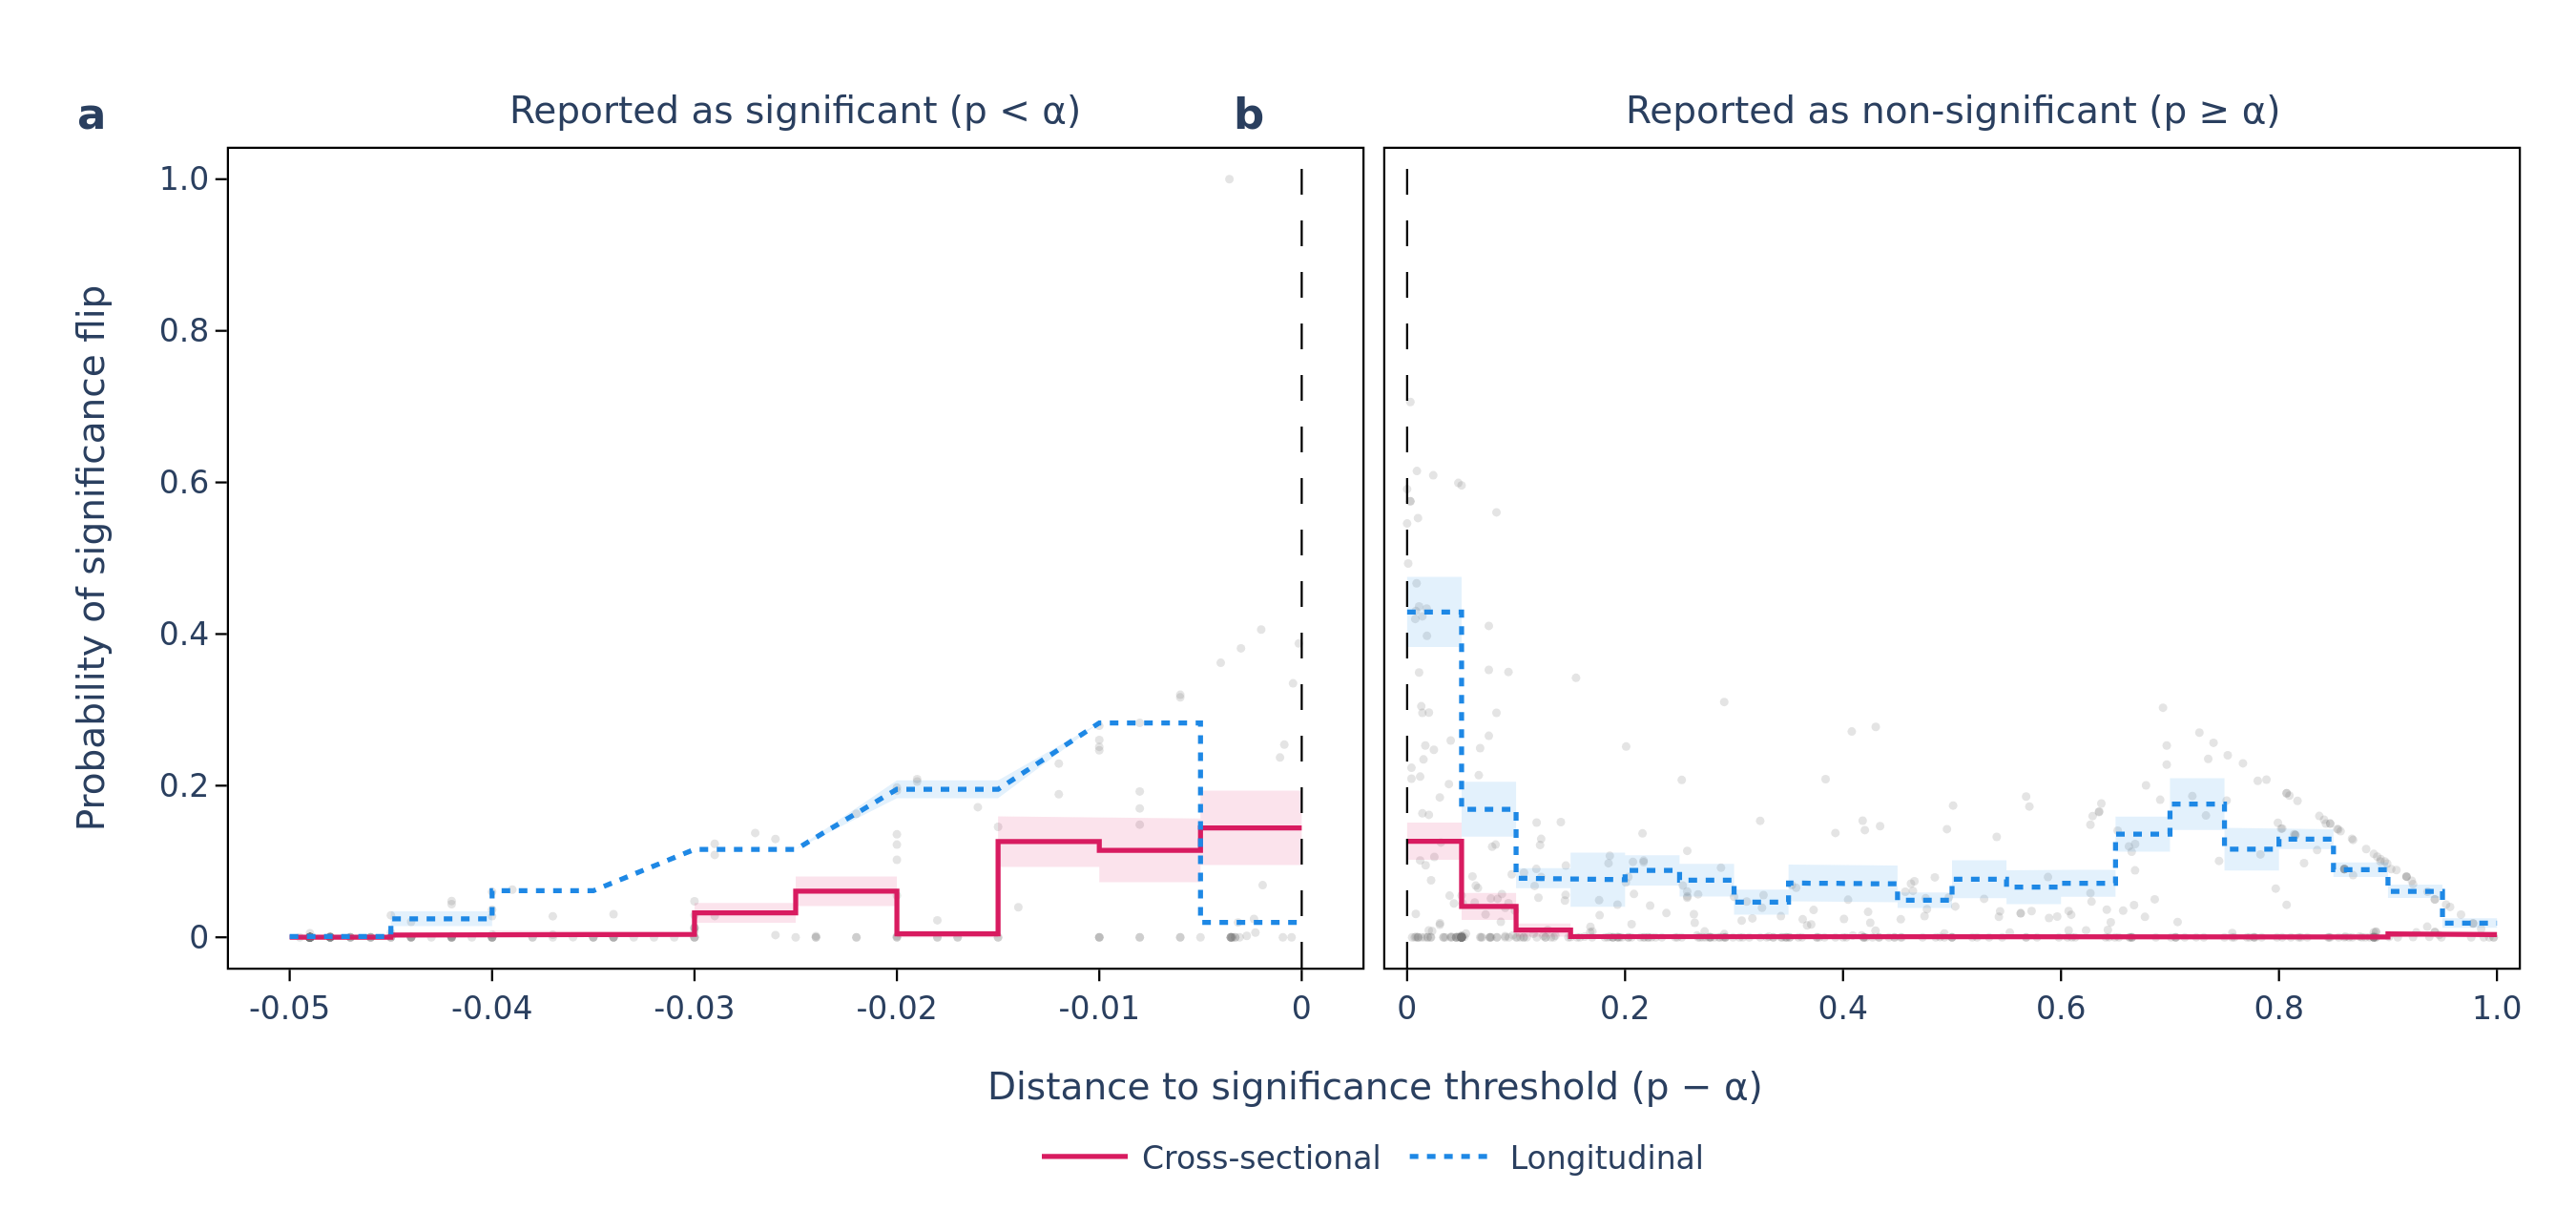

Saved to <living-park>/papers_data/figure-flip-probability.pdf


In [98]:
out_path = data_dir / "figure-flip-probability.pdf"
fig.write_image(str(out_path), scale=3, width=900, height=430)
display(Image(fig.to_image(format="png", width=900, height=430, scale=3)))
print(f"Saved to {anondir(out_path)}")